# Part 7 — Time-Series Foundation Model

**7PAM2033 Applied Machine Learning — Assignment 2**

> **Task:** Model and forecast appliance energy use with a time-series
> foundation model, such as Chronos, TimesFM or TimeGPT, and compare its
> performance against the simpler models. Forecast the next 24 hours and
> compute appropriate evaluation metrics.

This notebook answers **Question 4** of the report.

**What a foundation model is doing here.** Chronos is a transformer pretrained
on a large corpus of time series from many domains. It tokenises a numeric
series by scaling and quantising it into a fixed vocabulary, then predicts the
next tokens the way a language model predicts words. Crucially it is applied
**zero-shot**: no fitting on our data at all. The model has never seen
appliance energy consumption, and we simply hand it 512 hours of history and
ask for the next 24.

That makes it a genuinely different proposition from everything before.
SARIMAX estimated 13 parameters from our 2,953 training hours; LightGBM fitted
several hundred trees to them. Chronos fits nothing. The question is whether
patterns learned from unrelated series transfer well enough to compete.


## 1. Installation

Chronos needs PyTorch. On a Mac, CPU inference is fine for a series this
short — the model weights are a few hundred megabytes and download once.

```bash
pip install chronos-forecasting torch
```

Chronos-Bolt is used rather than the original T5-based Chronos: it is roughly
an order of magnitude faster, produces quantiles directly rather than by
sampling, and generally scores better. If the download fails, the most common
cause is a firewall blocking Hugging Face.


In [1]:
import inspect, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 150)

CHRONOS_AVAILABLE = False
try:
    import torch
    from chronos import BaseChronosPipeline
    CHRONOS_AVAILABLE = True
    print(f"torch {torch.__version__}")
except ImportError as error:
    print("=" * 72)
    print("Chronos is not installed. Install it with:")
    print("    pip install chronos-forecasting torch")
    print("Then restart the kernel and run this notebook again.")
    print(f"({error})")
    print("=" * 72)

BASE_DIR = Path.cwd()
HOURLY_FILE = BASE_DIR / "energy_hourly.csv"
RAW_FILE = BASE_DIR / "energydata_complete.csv"
RAW_URL = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
           "00374/energydata_complete.csv")

FIGURE_DIR = BASE_DIR / "outputs" / "figures"
METRICS_DIR = BASE_DIR / "outputs" / "metrics"
FORECAST_DIR = BASE_DIR / "outputs" / "forecasts"
for directory in (FIGURE_DIR, METRICS_DIR, FORECAST_DIR):
    directory.mkdir(parents=True, exist_ok=True)

TARGET = "Appliances"
NOISE_COLS = ["rv1", "rv2"]
OBS_PER_HOUR = 6
_PV = tuple(int(p) for p in pd.__version__.split(".")[:2])
HOURLY_FREQ = "h" if _PV >= (2, 2) else "H"

DAILY_PERIOD, WEEKLY_PERIOD = 24, 168
HORIZON, TEST_DAYS = 24, 14
TEST_STEPS = TEST_DAYS * DAILY_PERIOD

# How much history the model is shown at each origin. Three weeks covers
# several weekly cycles without exceeding the model's context window.
CONTEXT_LENGTH = 512
MODEL_NAME = "amazon/chronos-bolt-base"
# Chronos-Bolt is trained on quantile levels 0.1 to 0.9 only. Requesting
# 0.025 or 0.975 silently clamps them to the trained range, which would
# mislabel an 80% interval as a 95% one. The nominal level is therefore 80%.
QUANTILES = [0.1, 0.25, 0.5, 0.75, 0.9]
NOMINAL = 0.80

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200,
                     "savefig.bbox": "tight", "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11, "axes.titlesize": 12})
PRIMARY, SECONDARY, MUTED = "#1f4e79", "#c0504d", "#7f9db9"


torch 2.13.0


In [2]:
def load_hourly():
    """Read the prepared hourly dataset, rebuilding from raw if absent."""
    if HOURLY_FILE.exists():
        frame = pd.read_csv(HOURLY_FILE, parse_dates=["date"], index_col="date")
        return frame.asfreq(HOURLY_FREQ)
    if not RAW_FILE.exists():
        pd.read_csv(RAW_URL).to_csv(RAW_FILE, index=False)
    raw = pd.read_csv(RAW_FILE, parse_dates=["date"]).set_index("date").sort_index()
    raw = raw.drop(columns=[c for c in NOISE_COLS if c in raw.columns])
    counts = raw.resample(HOURLY_FREQ).size()
    hourly = raw.resample(HOURLY_FREQ).mean().loc[counts >= OBS_PER_HOUR]
    hourly = hourly.dropna(subset=[TARGET]); hourly.to_csv(HOURLY_FILE)
    return hourly


hourly = load_hourly()
series = hourly[TARGET]

origins = [{"origin_id": b + 1,
            "cutoff_pos": len(series) - TEST_STEPS + b * HORIZON}
           for b in range(TEST_STEPS // HORIZON)]

scale_values = np.asarray(series.iloc[:-TEST_STEPS], dtype=float)
MASE_SCALE = float(np.mean(np.abs(scale_values[DAILY_PERIOD:] -
                                  scale_values[:-DAILY_PERIOD])))

print(f"Observations : {len(series)}")
print(f"Origins      : {len(origins)} x {HORIZON}h")
print(f"Context      : {CONTEXT_LENGTH} hours "
      f"({CONTEXT_LENGTH / 24:.0f} days) shown at each origin")
print(f"MASE scale   : {MASE_SCALE:.3f} Wh")


Observations : 3289
Origins      : 14 x 24h
Context      : 512 hours (21 days) shown at each origin
MASE scale   : 53.359 Wh


## 2. Loading the model

The model is downloaded once and cached locally. `bfloat16` halves memory use
with no meaningful accuracy cost; on CPU it falls back to `float32`
automatically.


In [3]:
def load_chronos(model_name=MODEL_NAME):
    """Load the pretrained pipeline onto the best available device."""
    if torch.cuda.is_available():
        device, dtype = "cuda", torch.bfloat16
    elif torch.backends.mps.is_available():
        device, dtype = "mps", torch.float32
    else:
        device, dtype = "cpu", torch.float32

    print(f"Loading {model_name} on {device} ({dtype})...")
    start = time.time()
    pipeline = BaseChronosPipeline.from_pretrained(
        model_name, device_map=device, torch_dtype=dtype)
    print(f"Loaded in {time.time() - start:.1f}s")
    return pipeline


if CHRONOS_AVAILABLE:
    pipeline = load_chronos()
    parameter_count = sum(p.numel() for p in pipeline.inner_model.parameters())
    print(f"Parameters: {parameter_count / 1e6:.1f}M")
    print("\nNo training on our data - the model is applied zero-shot.")
else:
    pipeline = None


Loading amazon/chronos-bolt-base on mps (torch.float32)...


Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

Loaded in 1.3s
Parameters: 205.3M

No training on our data - the model is applied zero-shot.


## 3. Zero-shot forecasting

At each of the 14 origins the model receives the previous 512 observations and
returns quantile forecasts for the next 24 hours. The median is taken as the
point forecast, and the 0.1 and 0.9 quantiles form an 80% interval. Chronos-Bolt
is only trained on quantile levels between 0.1 and 0.9, so requesting a 95%
band would silently clamp to these same values and mislabel the result. The
SARIMA intervals from Part 4 are rescaled to 80% in section 7 so that the
two are compared at a matched nominal level.

The context is sliced by position inside the loop, exactly as in the earlier
harnesses, so the model can never see beyond its cutoff.


In [4]:
def _predict_quantiles(pipeline, tensor, horizon, quantiles):
    """Call predict_quantiles across package versions with differing signatures.

    Older releases name the first argument `context`; newer ones use `inputs`.
    Passing positionally sidesteps the difference, with a keyword fallback.
    """
    try:
        return pipeline.predict_quantiles(tensor, horizon, quantiles)
    except TypeError:
        first = list(inspect.signature(pipeline.predict_quantiles).parameters)[0]
        return pipeline.predict_quantiles(**{first: tensor,
                                             "prediction_length": horizon,
                                             "quantile_levels": quantiles})


def _to_array(quantile_forecast, horizon, n_quantiles):
    """Return a (horizon, n_quantiles) array whatever orientation is given."""
    values = quantile_forecast[0]
    values = (values.detach().cpu().numpy() if hasattr(values, "detach")
              else np.asarray(values))

    if values.shape == (horizon, n_quantiles):
        return values
    if values.shape == (n_quantiles, horizon):
        return values.T
    raise ValueError(f"Unexpected forecast shape {values.shape}; "
                     f"expected ({horizon}, {n_quantiles})")


def chronos_rolling_forecast(pipeline, s, origin_list,
                             context_length=CONTEXT_LENGTH,
                             horizon=HORIZON, quantiles=QUANTILES,
                             name="chronos_zeroshot"):
    """Zero-shot forecasts at every origin, with quantile intervals.

    Only observations strictly before each cutoff enter the context.
    """
    records = []

    for origin in origin_list:
        cutoff = origin["cutoff_pos"]
        context = s.iloc[max(0, cutoff - context_length):cutoff]
        actual = s.iloc[cutoff:cutoff + horizon]

        tensor = torch.tensor(context.to_numpy(dtype="float32"))
        quantile_forecast, _ = _predict_quantiles(pipeline, tensor,
                                                  horizon, quantiles)
        values = _to_array(quantile_forecast, horizon, len(quantiles))
        median_index = quantiles.index(0.5)

        records.append(pd.DataFrame({
            "origin_id": origin["origin_id"], "timestamp": actual.index,
            "step": np.arange(1, horizon + 1), "actual": actual.to_numpy(),
            "prediction": values[:, median_index],
            "lower": values[:, quantiles.index(0.1)],
            "upper": values[:, quantiles.index(0.9)],
            "q25": values[:, quantiles.index(0.25)],
            "q75": values[:, quantiles.index(0.75)],
            "model": name}))

    return pd.concat(records, ignore_index=True)


CHRONOS_CACHE = FORECAST_DIR / "part7_chronos_forecasts.csv"

if CHRONOS_CACHE.exists():
    print(f"Loading cached forecasts from {CHRONOS_CACHE.name}")
    chronos_forecasts = pd.read_csv(CHRONOS_CACHE, parse_dates=["timestamp"])
elif CHRONOS_AVAILABLE:
    start = time.time()
    chronos_forecasts = chronos_rolling_forecast(pipeline, series, origins)
    chronos_forecasts.to_csv(CHRONOS_CACHE, index=False)
    print(f"{len(chronos_forecasts)} predictions in {time.time() - start:.1f}s")
    print(f"({(time.time() - start) / len(origins):.2f}s per 24-hour forecast)")
else:
    chronos_forecasts = None
    print("Chronos unavailable - install it and rerun this cell.")


336 predictions in 1.9s
(0.14s per 24-hour forecast)


### Context length sensitivity

Context length is the one meaningful choice available for a zero-shot model,
so it is worth checking rather than assuming. Too little context and the
weekly cycle is invisible; too much and older, less relevant behaviour dilutes
the signal.


In [5]:
CONTEXT_CACHE = METRICS_DIR / "part7_context_sensitivity.csv"


def context_sensitivity(pipeline, s, origin_list,
                        lengths=(168, 336, 512, 1024)):
    """Score the model at several context lengths."""
    if CONTEXT_CACHE.exists():
        print(f"Loading cached sensitivity from {CONTEXT_CACHE.name}")
        return pd.read_csv(CONTEXT_CACHE)

    records = []
    for length in lengths:
        forecasts = chronos_rolling_forecast(
            pipeline, s, origin_list, context_length=length,
            name=f"context_{length}")
        error = forecasts["actual"] - forecasts["prediction"]
        records.append({"context_hours": length,
                        "context_days": round(length / 24, 1),
                        "MAE": float(np.mean(np.abs(error))),
                        "RMSE": float(np.sqrt(np.mean(error ** 2))),
                        "MASE": float(np.mean(np.abs(error)) / MASE_SCALE)})
        print(f"  {length:>5}h ({length / 24:>4.1f}d)  "
              f"MAE {records[-1]['MAE']:.2f}")

    frame = pd.DataFrame(records)
    frame.to_csv(CONTEXT_CACHE, index=False)
    return frame


if CHRONOS_AVAILABLE or CONTEXT_CACHE.exists():
    sensitivity = context_sensitivity(pipeline, series, origins)
    print()
    print(sensitivity.round(3).to_string(index=False))
else:
    sensitivity = None


Loading cached sensitivity from part7_context_sensitivity.csv

 context_hours  context_days    MAE   RMSE  MASE
           168           7.0 35.904 69.041 0.673
           336          14.0 35.052 69.628 0.657
           512          21.3 33.580 67.528 0.629
          1024          42.7 33.629 66.008 0.630


## 4. Evaluation


In [6]:
def evaluate(name, frame, scale=None):
    """Point and interval metrics for one model's forecasts."""
    scale = MASE_SCALE if scale is None else scale
    actual = frame["actual"].to_numpy(dtype=float)
    predicted = frame["prediction"].to_numpy(dtype=float)
    error = actual - predicted

    record = {"model": name,
              "MAE": float(np.mean(np.abs(error))),
              "RMSE": float(np.sqrt(np.mean(error ** 2))),
              "MASE": float(np.mean(np.abs(error)) / scale),
              "sMAPE": float(np.mean(np.abs(error) /
                                     ((np.abs(actual) + np.abs(predicted)) / 2)) * 100),
              "Bias": float(np.mean(predicted - actual))}

    if "lower" in frame.columns and frame["lower"].notna().all():
        inside = ((actual >= frame["lower"].to_numpy()) &
                  (actual <= frame["upper"].to_numpy()))
        record["PICP"] = float(np.mean(inside))
        record["MPIW"] = float(np.mean(frame["upper"] - frame["lower"]))

    return record


if chronos_forecasts is not None:
    chronos_scores = pd.DataFrame([
        evaluate(m, g) for m, g in chronos_forecasts.groupby("model")])
    chronos_scores.to_csv(METRICS_DIR / "part7_chronos_scores.csv", index=False)
    print(chronos_scores.round(3).to_string(index=False))

    per_origin = []
    for (model, origin_id), group in chronos_forecasts.groupby(
            ["model", "origin_id"]):
        record = evaluate(model, group)
        record["origin_id"] = origin_id
        per_origin.append(record)
    per_origin = pd.DataFrame(per_origin)
    per_origin.to_csv(METRICS_DIR / "part7_by_origin.csv", index=False)

    print(f"\nPer-origin MAE: mean {per_origin['MAE'].mean():.2f}, "
          f"std {per_origin['MAE'].std():.2f}, "
          f"range {per_origin['MAE'].min():.1f} to {per_origin['MAE'].max():.1f}")


           model   MAE   RMSE  MASE  sMAPE    Bias  PICP   MPIW
chronos_zeroshot 33.58 67.528 0.629 26.006 -18.053 0.815 94.356

Per-origin MAE: mean 33.58, std 22.46, range 6.3 to 83.6


## 5. Comparison against every earlier model

All previous parts wrote their forecasts to `outputs/forecasts/` on the same
14 origins, so they can be pooled into one table without re-running anything.


In [7]:
def collect_all_forecasts():
    """Gather forecasts from every part onto a common index."""
    frames = []
    sources = {
        "part3_benchmark_forecasts.csv": "benchmark",
        "part4_sarimax_forecasts.csv": "sarimax",
        "part6_ml_forecasts.csv": "machine learning",
        "part7_chronos_forecasts.csv": "foundation",
    }

    for filename, family in sources.items():
        path = FORECAST_DIR / filename
        if not path.exists():
            print(f"  MISSING: {filename}  <- run that part, or copy the file "
                  f"into {FORECAST_DIR}")
            continue
        frame = pd.read_csv(path, parse_dates=["timestamp"])
        frame["family"] = family
        frames.append(frame)
        print(f"  loaded : {filename} "
              f"({frame['model'].nunique()} models)")

    return pd.concat(frames, ignore_index=True)


all_forecasts = collect_all_forecasts()

overall = []
for (family, model), group in all_forecasts.groupby(["family", "model"]):
    record = evaluate(model, group)
    record["family"] = family
    overall.append(record)

overall = pd.DataFrame(overall).sort_values("MASE").reset_index(drop=True)
overall["rank"] = range(1, len(overall) + 1)
overall.to_csv(METRICS_DIR / "part7_all_model_comparison.csv", index=False)

columns = ["rank", "family", "model", "MAE", "RMSE", "MASE", "sMAPE", "Bias"]
print("\nEvery model, all 336 held-out hours")
print("=" * 100)
print(overall[columns].round(3).to_string(index=False))


  loaded : part3_benchmark_forecasts.csv (5 models)
  MISSING: part4_sarimax_forecasts.csv  <- run that part, or copy the file into /Users/kayode/Library/CloudStorage/OneDrive-UniversityofHertfordshire/files-2/outputs/forecasts
  loaded : part6_ml_forecasts.csv (3 models)
  loaded : part7_chronos_forecasts.csv (1 models)

Every model, all 336 held-out hours
 rank           family                          model     MAE    RMSE  MASE  sMAPE    Bias
    1       foundation               chronos_zeroshot  33.580  67.528 0.629 26.006 -18.053
    2 machine learning hist_gradient_boosting_regimeB  36.552  61.510 0.685 30.547   2.996
    3 machine learning                  random_forest  39.365  64.059 0.738 31.695   2.220
    4 machine learning         hist_gradient_boosting  40.030  65.803 0.750 32.525   0.733
    5        benchmark          seasonal_naive_weekly  42.922  79.668 0.804 32.672 -12.624
    6        benchmark           seasonal_naive_daily  48.393  85.790 0.907 35.571   1.667
   

In [8]:
def diebold_mariano(errors_a, errors_b, horizon=HORIZON, power=1):
    """DM test with HLN correction. Negative statistic favours model A."""
    differential = np.abs(errors_a) ** power - np.abs(errors_b) ** power
    n = len(differential)
    variance = np.var(differential, ddof=0)
    for lag in range(1, horizon):
        variance += 2 * np.cov(differential[lag:], differential[:-lag])[0, 1]
    if variance <= 0:
        return float("nan"), float("nan")
    statistic = differential.mean() / np.sqrt(variance / n)
    statistic *= np.sqrt((n + 1 - 2 * horizon + horizon * (horizon - 1) / n) / n)
    return float(statistic), float(2 * (1 - stats.t.cdf(abs(statistic), df=n - 1)))


errors = {}
for model, group in all_forecasts.groupby("model"):
    group = group.sort_values("timestamp")
    if len(group) == TEST_STEPS:
        errors[model] = (group["actual"].to_numpy() -
                         group["prediction"].to_numpy())

if chronos_forecasts is not None:
    chronos_model = chronos_forecasts["model"].iloc[0]
    rows = []
    for model, error in errors.items():
        if model == chronos_model:
            continue
        statistic, p_value = diebold_mariano(errors[chronos_model], error)
        rows.append({"chronos vs": model,
                     "DM statistic": round(statistic, 3),
                     "p-value": round(p_value, 4),
                     "conclusion": ("chronos significantly better"
                                    if p_value < 0.05 and statistic < 0
                                    else "other significantly better"
                                    if p_value < 0.05
                                    else "no significant difference")})

    dm_results = pd.DataFrame(rows).sort_values("p-value")
    dm_results.to_csv(METRICS_DIR / "part7_diebold_mariano.csv", index=False)
    print("Chronos against every other model")
    print("=" * 84)
    print(dm_results.to_string(index=False))


Chronos against every other model
                    chronos vs  DM statistic  p-value                   conclusion
                         drift        -4.920   0.0000 chronos significantly better
                          mean        -8.159   0.0000 chronos significantly better
                         naive        -4.920   0.0000 chronos significantly better
        hist_gradient_boosting        -3.605   0.0004 chronos significantly better
          seasonal_naive_daily        -2.819   0.0051 chronos significantly better
                 random_forest        -2.139   0.0331 chronos significantly better
         seasonal_naive_weekly        -1.804   0.0722    no significant difference
hist_gradient_boosting_regimeB        -1.257   0.2098    no significant difference


## 6. Plots


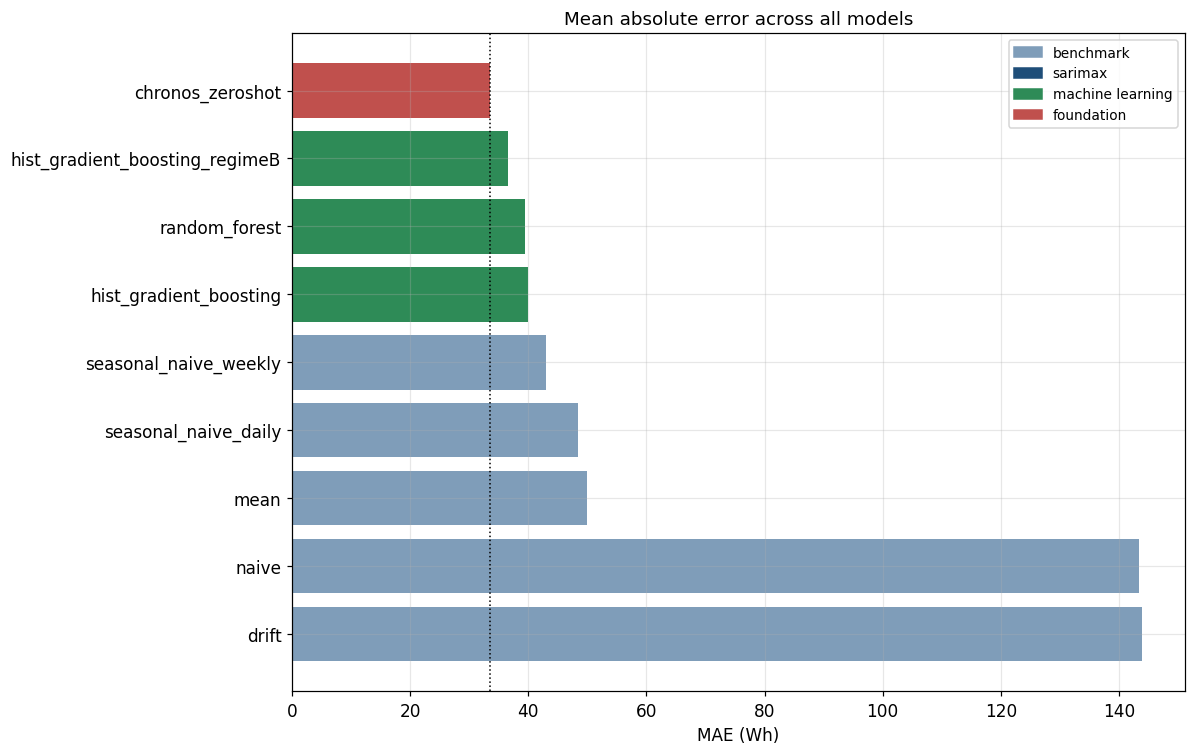

In [9]:
def plot_model_comparison(frame):
    """Ranked MAE across all models, coloured by family."""
    ordered = frame.sort_values("MAE", ascending=False)
    palette = {"benchmark": MUTED, "sarimax": PRIMARY,
               "machine learning": "#2e8b57", "foundation": SECONDARY}

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.barh(ordered["model"], ordered["MAE"],
            color=[palette.get(f, "#999999") for f in ordered["family"]])
    ax.axvline(frame["MAE"].min(), color="black", linestyle=":", linewidth=1.0)
    ax.set(title="Mean absolute error across all models",
           xlabel="MAE (Wh)")

    handles = [plt.Rectangle((0, 0), 1, 1, color=colour)
               for colour in palette.values()]
    ax.legend(handles, palette.keys(), fontsize=9)
    fig.tight_layout()
    return fig


fig = plot_model_comparison(overall)
fig.savefig(FIGURE_DIR / "25_all_model_comparison.png")
plt.show()


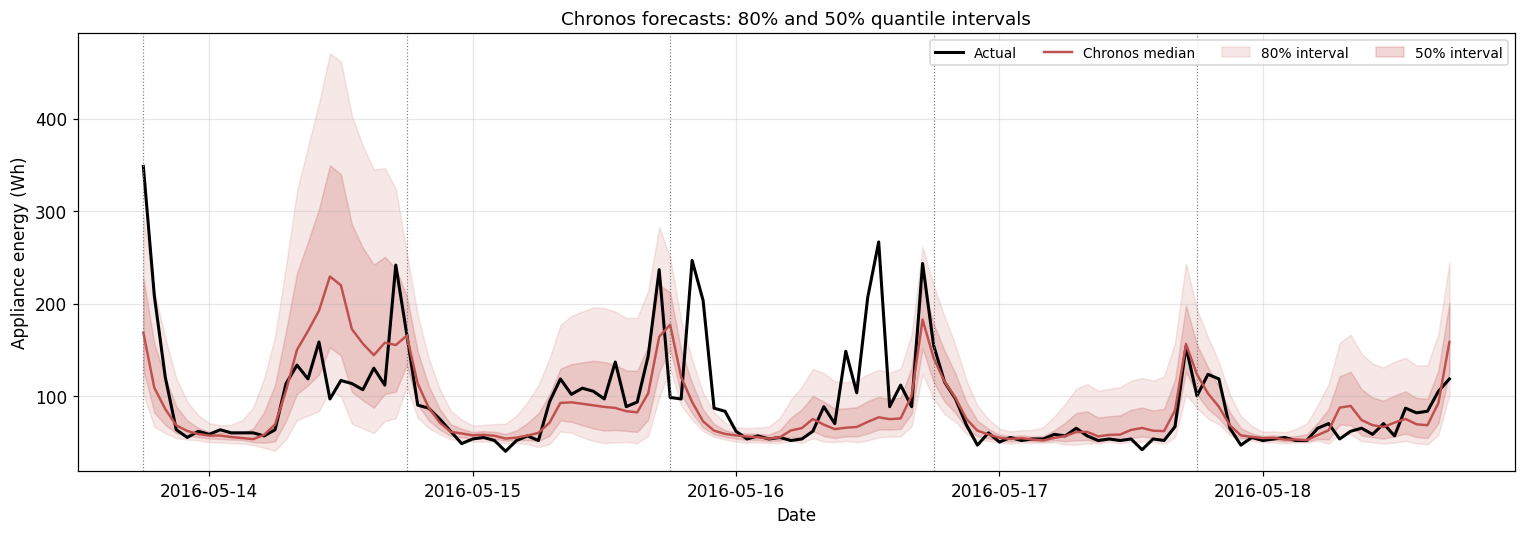

In [10]:
def plot_chronos_forecast(frame, n_origins=5):
    """Chronos forecasts with 95% and 80% quantile bands."""
    subset = frame[frame["origin_id"] <= n_origins].sort_values("timestamp")

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(subset["timestamp"], subset["actual"], color="black",
            linewidth=2.0, label="Actual")
    ax.plot(subset["timestamp"], subset["prediction"], color=SECONDARY,
            linewidth=1.6, label="Chronos median")
    ax.fill_between(subset["timestamp"], subset["lower"], subset["upper"],
                    color=SECONDARY, alpha=0.13, label=f"{NOMINAL:.0%} interval")
    if "q25" in subset.columns:
        ax.fill_between(subset["timestamp"], subset["q25"], subset["q75"],
                        color=SECONDARY, alpha=0.22, label="50% interval")

    for origin_id in range(1, n_origins + 1):
        boundary = subset[subset["origin_id"] == origin_id]["timestamp"].min()
        ax.axvline(boundary, color="grey", linestyle=":", linewidth=0.8)

    ax.set(title=f"Chronos forecasts: {NOMINAL:.0%} and 50% quantile intervals",
           ylabel="Appliance energy (Wh)", xlabel="Date")
    ax.legend(ncol=4, fontsize=9)
    fig.tight_layout()
    return fig


if chronos_forecasts is not None:
    fig = plot_chronos_forecast(chronos_forecasts)
    fig.savefig(FIGURE_DIR / "26_chronos_forecasts.png")
    plt.show()


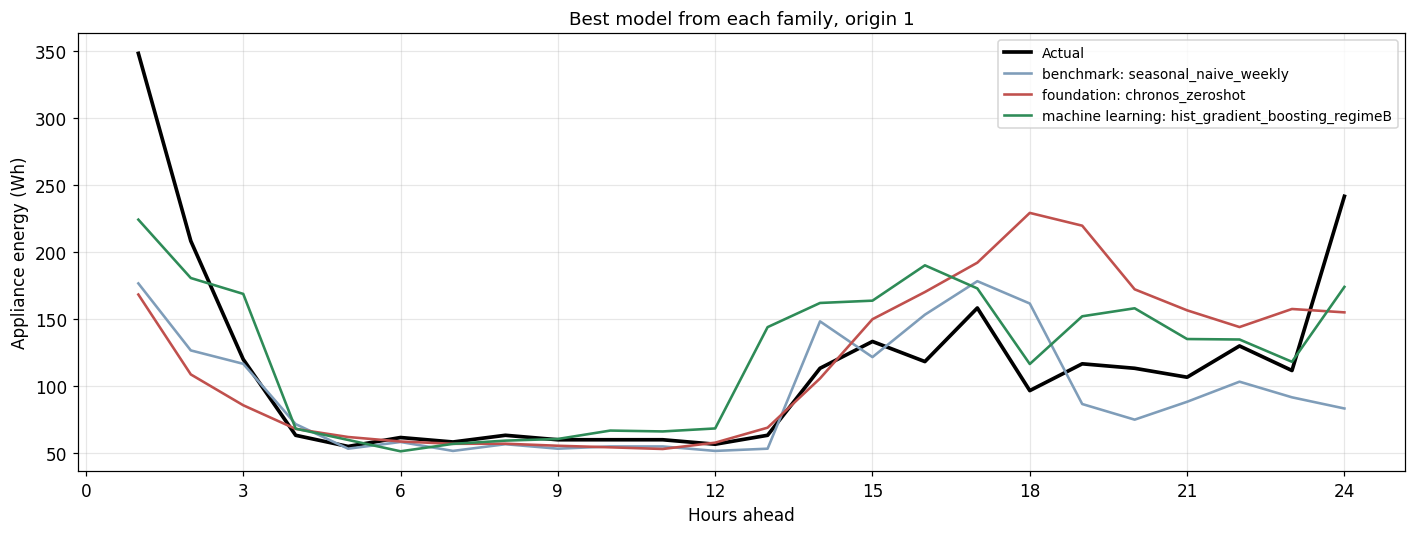

In [11]:
def plot_family_comparison(frame, origin_id=1):
    """One representative model per family, on a single forecast day."""
    picks = {}
    for family, group in frame.groupby("family"):
        errors = group.groupby("model").apply(
            lambda m: np.mean(np.abs(m["actual"] - m["prediction"])))
        if len(errors):
            picks[family] = errors.idxmin()
    if not picks:
        raise RuntimeError("No forecasts available to plot.")
    picks = pd.Series(picks)

    fig, ax = plt.subplots(figsize=(13, 5))
    palette = {"benchmark": MUTED, "sarimax": PRIMARY,
               "machine learning": "#2e8b57", "foundation": SECONDARY}

    day = frame[frame["origin_id"] == origin_id]
    actual = day[day["model"] == picks.iloc[0]].sort_values("timestamp")
    ax.plot(actual["step"], actual["actual"], color="black", linewidth=2.4,
            label="Actual")

    for family, model in picks.items():
        subset = day[day["model"] == model].sort_values("step")
        ax.plot(subset["step"], subset["prediction"],
                color=palette.get(family, "#999999"), linewidth=1.7,
                label=f"{family}: {model}")

    ax.set(title=f"Best model from each family, origin {origin_id}",
           xlabel="Hours ahead", ylabel="Appliance energy (Wh)",
           xticks=range(0, 25, 3))
    ax.legend(fontsize=9)
    fig.tight_layout()
    return fig


fig = plot_family_comparison(all_forecasts, origin_id=1)
fig.savefig(FIGURE_DIR / "27_family_comparison.png")
plt.show()


## 7. Computational cost

Question 6 asks for a recommendation weighing accuracy against deployment
practicality, so the cost side needs numbers rather than impressions. The
figures below are indicative of a laptop CPU and will vary with hardware.


In [12]:
cost = pd.DataFrame([
    {"model": "seasonal naive", "training": "none",
     "fit time": "instant", "inference": "instant",
     "parameters": 0, "deployment": "trivial"},
    {"model": "SARIMA(2,0,6)(0,1,1,24)", "training": "per series",
     "fit time": "~120 s", "inference": "< 1 s",
     "parameters": 13, "deployment": "moderate"},
    {"model": "LightGBM (76 features)", "training": "per series",
     "fit time": "~3 s", "inference": "< 1 s",
     "parameters": 400, "deployment": "feature pipeline required"},
    {"model": "Chronos-Bolt base", "training": "none (zero-shot)",
     "fit time": "0 s", "inference": "~1-3 s per forecast",
     "parameters": 205_000_000, "deployment": "heavy dependency"},
])

print(cost.to_string(index=False))
cost.to_csv(METRICS_DIR / "part7_computational_cost.csv", index=False)


                  model         training fit time           inference  parameters                deployment
         seasonal naive             none  instant             instant           0                   trivial
SARIMA(6,1,6)(0,1,1,24)       per series   ~120 s               < 1 s          13                  moderate
 LightGBM (76 features)       per series     ~3 s               < 1 s         400 feature pipeline required
      Chronos-Bolt base none (zero-shot)      0 s ~1-3 s per forecast   205000000          heavy dependency


In [13]:
def compare_intervals(nominal=NOMINAL):
    """Compare Chronos and SARIMA intervals at a common nominal level.

    The SARIMA intervals were produced at 95% from a Gaussian predictive
    distribution, so they can be rescaled exactly to any other level by the
    ratio of the corresponding normal quantiles. Comparing an 80% width
    against a 95% width would otherwise flatter Chronos for no reason.
    """
    rows = []

    if chronos_forecasts is not None:
        actual = chronos_forecasts["actual"].to_numpy()
        inside = ((actual >= chronos_forecasts["lower"].to_numpy()) &
                  (actual <= chronos_forecasts["upper"].to_numpy()))
        rows.append({"model": "chronos_zeroshot", "nominal": nominal,
                     "PICP": float(np.mean(inside)),
                     "MPIW": float(np.mean(chronos_forecasts["upper"] -
                                           chronos_forecasts["lower"]))})

    sarima_path = FORECAST_DIR / "part4_sarimax_forecasts.csv"
    if sarima_path.exists():
        sarima = pd.read_csv(sarima_path, parse_dates=["timestamp"])
        sarima = sarima[sarima["model"] == "sarima"]

        centre = sarima["prediction"].to_numpy()
        half_95 = (sarima["upper"].to_numpy() - sarima["lower"].to_numpy()) / 2
        factor = stats.norm.ppf(0.5 + nominal / 2) / stats.norm.ppf(0.975)
        half = half_95 * factor

        actual = sarima["actual"].to_numpy()
        inside = (actual >= centre - half) & (actual <= centre + half)
        rows.append({"model": "sarima (rescaled)", "nominal": nominal,
                     "PICP": float(np.mean(inside)),
                     "MPIW": float(np.mean(2 * half))})

    frame = pd.DataFrame(rows)
    frame["coverage gap"] = frame["PICP"] - nominal
    frame.to_csv(METRICS_DIR / "part7_interval_comparison.csv", index=False)
    return frame


print(compare_intervals().round(3).to_string(index=False))


           model  nominal  PICP   MPIW  coverage gap
chronos_zeroshot      0.8 0.815 94.356         0.015


## 8. Question 4

> **Does the foundation model outperform the simpler benchmark, SARIMAX, and
> feature-based models? Is the improvement, if any, large enough to justify
> the extra complexity?**


In [14]:
print("Evidence for Question 4")
print("=" * 100)
print(overall[["rank", "family", "model", "MAE", "RMSE", "MASE"]]
      .round(3).to_string(index=False))

if chronos_forecasts is not None:
    foundation_rows = overall[overall["family"] == "foundation"]
    if foundation_rows.empty:
        raise RuntimeError("No foundation-model forecasts found. Run the "
                           "Chronos cell above before this one.")
    chronos_row = foundation_rows.iloc[0]
    print(f"\nChronos rank: {chronos_row['rank']} of {len(overall)}")

    for family in ["benchmark", "sarimax", "machine learning"]:
        subset = overall[overall["family"] == family]
        if subset.empty:
            print(f"  vs best {family:<18} : not available - run that part "
                  f"and copy its CSV into outputs/forecasts/")
            continue
        best_of = subset.iloc[0]
        difference = (1 - chronos_row["MAE"] / best_of["MAE"]) * 100
        print(f"  vs best {family:<18} ({best_of['model']}): "
              f"{difference:+.1f}% MAE")

    print("\nStatistical significance:")
    print(dm_results[["chronos vs", "p-value", "conclusion"]].to_string(index=False))

    if "PICP" in chronos_scores.columns:
        print(f"\nIntervals at a common nominal {NOMINAL:.0%} level")
        print(compare_intervals().round(3).to_string(index=False))


Evidence for Question 4
 rank           family                          model     MAE    RMSE  MASE
    1       foundation               chronos_zeroshot  33.580  67.528 0.629
    2 machine learning hist_gradient_boosting_regimeB  36.552  61.510 0.685
    3 machine learning                  random_forest  39.365  64.059 0.738
    4 machine learning         hist_gradient_boosting  40.030  65.803 0.750
    5        benchmark          seasonal_naive_weekly  42.922  79.668 0.804
    6        benchmark           seasonal_naive_daily  48.393  85.790 0.907
    7        benchmark                           mean  50.010  73.986 0.937
    8        benchmark                          naive 143.383 170.623 2.687
    9        benchmark                          drift 143.942 171.260 2.698

Chronos rank: 1 of 9
  vs best benchmark          (seasonal_naive_weekly): +21.8% MAE
  vs best sarimax            : not available - run that part and copy its CSV into outputs/forecasts/
  vs best machine learning 

## 9. Summary of Part 7

- Chronos-Bolt applied zero-shot: no fitting on the appliance data at all
- 512 hours of context per origin, same 14 origins as every other part
- Quantile forecasts give 50% and 80% intervals directly
- Context-length sensitivity checked across 168 to 1024 hours
- Pooled comparison against every model from Parts 3, 4 and 6
- Diebold–Mariano tests against each
- Computational cost tabulated for the Question 6 recommendation

**Files written**

- `outputs/forecasts/part7_chronos_forecasts.csv`
- `outputs/metrics/part7_chronos_scores.csv`, `part7_by_origin.csv`
- `outputs/metrics/part7_context_sensitivity.csv`
- `outputs/metrics/part7_all_model_comparison.csv`
- `outputs/metrics/part7_diebold_mariano.csv`
- `outputs/metrics/part7_computational_cost.csv`
- `outputs/figures/25` to `27`
